# Project 03: Gibbs Sampling (Random Algorithm)

In [5]:
import random
import numpy as np
import seqlogo as sl
from motif_ops import *
from seq_ops import reverse_complement

## Input Data
To get input data, peaks calling was obtained using CHIP-seq data with an FDR cutoff of 0.05. As BAM format was utilized, only the left mate (5' end) tag of the paired end was used during the pileup.

The data was filtered in two steps. First, peaks were filtered by width, only keeping peaks from 100-1000 bp (528 -> 523). It was further filtered by signal strength, keepling only those above the 75th percentile of summit height (signalValue, resulting in 138 high-confidence peaks.

From those peaks, we found the summit position and extracted 50 nucleotides downstream and upstream of the summit. We assumed the p53 motif would lay near the summit. The background sequences are the bp that are not included in the motif search window.

In [6]:
motif_file = "motif_sequences.csv"
sequences = [seq.strip() for seq in open(motif_file)]

background_file = "background_sequences.csv"
background_sequences = [seq.strip() for seq in open(background_file)]

---
# Project Start

In [363]:
def calculate_background(sequences: List[str]):
    # Initialize Background
    background_counts = {'A': 0, 'C': 0, 'G': 0, 'T': 0}
    for non_motif in sequences:
        for nucleotide in non_motif:
            if nucleotide.upper() in background_counts:  # Skip N
                background_counts[nucleotide.upper()] += 1

    # After getting counts convert into frequency
    total_background = sum(background_counts.values())
    #bg_freqs = {nucleotide: round(count/total_background, 3) for nucleotide, count in background_counts.items()}

    bg_freqs = np.array([
        round(background_counts['A'] / total_background, 3),
        round(background_counts['C'] / total_background, 3),
        round(background_counts['G'] / total_background,3),
        round(background_counts['T'] / total_background, 3)
    ])
    return bg_freqs

In [390]:
def GibbsMotifFinder (seqs, k, seed=None, max_iterations = 10000):
    '''
    Function to find a pfm from a list of strings using a Gibbs sampler
    
    Args: 
        seqs (str list): a list of sequences, not necessarily in same lengths
        k (int): the length of motif to find
        seed (int, default=None): seed for np.random

    Returns:
        pfm (numpy array): dimensions are 4xlength
    '''
    # Use rng to make random samples/selections/numbers
    # Example: randint = rng.integer(1, 10)
    random.seed(seed)
    rng = np.random.default_rng(seed)

    #### INITIALIZATION ####
    # Get starting positions of motifs for all sequences
    random_starting_positions = [rng.integers(0, (len(seq) - k)) for seq in seqs]

    # Initialize PFM
    # Extract k-mers using random_starting_positions
    kmers = [seq[pos:pos + k] for seq, pos in zip(seqs, random_starting_positions)]
    pfm = build_pfm(kmers, k)

    # Initialize Background
    #bg_freq = calculate_background(seqs, random_starting_positions, k)
    bg_freq = calculate_background(background_sequences)
    # Initialize PWM
    pwm = build_pwm(pfm, bg=bg_freq, p=0.25)
    pwm = np.round(pwm, 3)

    #### ITERATION ####
    threshold_counter = 0
    convergence_history= []
    prior_pwm = None
    for iteration in range(max_iterations):
        seq_indices = np.arange(len(seqs))
        rng.shuffle(seq_indices)
        for seq_index in seq_indices:
            sequence = seqs[seq_index]
            kmers_with_seq_removed = kmers[:seq_index] + kmers[seq_index+1:]

            # Recalculate PWM omitting the chosen sequence
            recalculated_pfm = build_pfm(kmers_with_seq_removed, k)
            recalculated_pwm = np.round(build_pwm(recalculated_pfm, bg=bg_freq, p=0.25), 3)


            # Score all possible positions in this sequence
            sequence_scores = []

            for start_pos in range(len(sequence)-k+1):
                kmer = sequence[start_pos:start_pos+k]
                score = score_kmer(kmer, recalculated_pwm)

                sequence_scores.append(round(float(score),3)) # for test should have 91 scores x 5 iterations

            # print(sequence_scores)
            # print(len(sequence_scores)

            # Select new position using weighted random
            # Convert scores to probabilities
            #exp_scores = np.exp(sequence_scores)
            #scores_probs = exp_scores / np.sum(exp_scores)
            # Convert from log 2
            converted_scores = [2 ** score for score in sequence_scores]
            scores_probs = np.array(converted_scores) / sum(converted_scores)
            seq_new_start_pos = rng.choice(np.arange(stop = len(sequence)-k+1), p = scores_probs)

            # Update new starting position
            random_starting_positions[seq_index] = seq_new_start_pos
            # Get new kmer and add it to list of kmers
            kmer = sequence[seq_new_start_pos:seq_new_start_pos+k]
            kmers[seq_index] = kmer

        if iteration % 10 == 0 and iteration > 30:

            full_pfm = build_pfm(kmers, k)
            full_pwm = build_pwm(full_pfm, bg=bg_freq, p=0.25)
            if prior_pwm is None:
                prior_pwm = full_pwm
            else:

                pwm_diff = np.linalg.norm(full_pwm - prior_pwm) / np.linalg.norm(prior_pwm)
                print(f"max_iterations = {max_iterations}")
                print(f'{iteration} iterations completed,')
                print(f'Frobenius diff: {pwm_diff}')
                ic = pfm_ic(recalculated_pfm)
                print(f'IC: {ic}')
                if pwm_diff < 0.05:
                    threshold_counter += 1
                else:
                    threshold_counter = 0
                if threshold_counter >= 3:
                    print(f'{iteration} iterations completed,')
                    print(f'Frobenius diff: {pwm_diff}')
                    ic = pfm_ic(recalculated_pfm)
                    print(f'IC: {ic}')
                    return full_pfm
                prior_pwm = full_pwm
                convergence_history.append(pwm_diff)

    print(f"Did not converge after {max_iterations} iterations. Diff statistics:")
    print(f" Min: {min(convergence_history)}")
    print(f" Mean: {np.mean(convergence_history)}")
    print(f" Std: {np.std(convergence_history)}")
    if len(convergence_history) > 20:
        suggested_threshold = np.percentile(convergence_history, 10)
        method = "10th percentile"
    else:
        suggested_threshold = min(covergence_history) + (0.5 * np.std(convergence_history))
        method = " min + 0.5*std"
    print(f"Suggested threshold ({method}): {suggested_threshold:.3f}")

    return full_pfm



In [391]:
subsample_pfm = GibbsMotifFinder(seqs=sequences, k=38, seed=42)

max_iterations = 10000
50 iterations completed,
Frobenius diff: 0.08106877452205324
IC: 23.321398482425295
max_iterations = 10000
60 iterations completed,
Frobenius diff: 0.08202585796481975
IC: 23.16886805523022
max_iterations = 10000
70 iterations completed,
Frobenius diff: 0.04955215090316589
IC: 23.559003210021768
max_iterations = 10000
80 iterations completed,
Frobenius diff: 0.17184686451965459
IC: 23.167264412531726
max_iterations = 10000
90 iterations completed,
Frobenius diff: 0.1712253880847027
IC: 23.381494041554827
max_iterations = 10000
100 iterations completed,
Frobenius diff: 0.203797559139056
IC: 23.249991380008986
max_iterations = 10000
110 iterations completed,
Frobenius diff: 0.18739426385123403
IC: 23.330777558849803
max_iterations = 10000
120 iterations completed,
Frobenius diff: 0.22815651451487035
IC: 23.168914046302472
max_iterations = 10000
130 iterations completed,
Frobenius diff: 0.22369981488253918
IC: 23.134247098030755
max_iterations = 10000
140 iterations

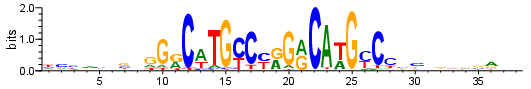

In [386]:
sl.seqlogo(sl.CompletePm(pfm = subsample_pfm.T))
#print(subsample_pfm)
#ic_scores = pfm_ic(subsample_pfm)
#print(ic_scores)

---
# Driver Program
Don't change any of the code here. If you have completed the project by following the coding by contract, the following code should work.

In [ ]:
# Run the gibbs sampler:
promoter_pfm = GibbsMotifFinder(seqs,10 )

# Plot the final pfm that is generated: 
seqlogo.seqlogo(seqlogo.CompletePm(pfm = promoter_pfm.T))

In [ ]:
def get_consensus_sequence(pwm, threshold):
    pass
